## TC 5033
### Word Embeddings

<br>

#### Activity 3a: Exploring Word Embeddings with GloVe and Numpy
<br>

- Objective:
    - To understand the concept of word embeddings and their significance in Natural Language Processing.
    - To learn how to manipulate and visualize high-dimensional data using dimensionality reduction techniques like PCA and t-SNE.
    - To gain hands-on experience in implementing word similarity and analogies using GloVe embeddings and Numpy.
    
<br>

- Instructions:
    - Download GloVe pre-trained vectors from the provided link in Canvas, the official public project: 
    Jeffrey Pennington, Richard Socher, and Christopher D. Manning. 2014. GloVe: Global Vectors for Word Representation
    https://nlp.stanford.edu/data/glove.6B.zip

    - Create a dictorionay of the embeddings so that you carry out fast look ups. Save that dictionary e.g. as a serialized file for faster loading in future uses.
    
    - PCA and t-SNE Visualization: After loading the GloVe embeddings, use Numpy and Sklearn to perform PCA and t-SNE to reduce the dimensionality of the embeddings and visualize them in a 2D or 3D space.

    - Word Similarity: Implement a function that takes a word as input and returns the 'n' most similar words based on their embeddings. You should use Numpy to implement this function, using libraries that already implement this function (e.g. Gensim) will result in zero points.

    - Word Analogies: Implement a function to solve analogies between words. For example, "man is to king as woman is to ____". You should use Numpy to implement this function, using libraries that already implement this function (e.g. Gensim) will result in zero points.

    - Submission: This activity is to be submitted in teams of 3 or 4. Only one person should submit the final work, with the full names of all team members included in a markdown cell at the beginning of the notebook.
    
<br>

- Evaluation Criteria:

    - Code Quality (40%): Your code should be well-organized, clearly commented, and easy to follow. Use also markdown cells for clarity.
    
   - Functionality (60%): All functions should work as intended, without errors.
       - Visualization of PCA and t-SNE (10% each for a total of 20%)
       - Similarity function (20%)
       - Analogy function (20%)
|



#### Import libraries

In [1]:
# Import libraries
import torch
import torch.nn.functional as F
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
from numpy.linalg import norm
import pickle
plt.style.use('ggplot')

#### Load file

### Loading GloVe embeddings

The variable `PATH` points to the GloVe text file, where each line has one word followed by its embedding values.  
For example, in `glove.6B.50d.txt` each word is represented by a 50‑dimensional vector, so we set `emb_dim = 50`.  
These pre‑trained embeddings capture semantic information about words, learned from large text corpora.  
We will use this file as the source to build our own Python dictionary of word → vector mappings.


In [2]:
# PATH = '/media/pepe/DataUbuntu/Databases/glove_embeddings/glove.6B.200d.txt'
PATH = './glove_embeddings/glove.6B.50d.txt'
emb_dim = 50

### Creating an embedding dictionary

We create a Python dictionary to map each word to its corresponding embedding vector.  
The function `create_emb_dictionary` reads the GloVe file line by line, splits each line, and interprets the first token as the word and the remaining tokens as the embedding coordinates.  
These coordinates are converted into NumPy arrays of type `float32`, giving us efficient numerical vectors for later computations.  
This dictionary allows constant‑time lookups of word embeddings, which is essential for similarity and analogy operations.


In [3]:
# Create dictionary with embeddings

def create_emb_dictionary(path):
    embeddings_dict = {}
    
    # Open the GloVe file in read mode
    with open(path, 'r', encoding='utf-8') as f:

        # Iterate line by line
        for line in f:

            # Split line into tokens (word + numbers)
            parts = line.strip().split()
            
            # First element is the word
            word = parts[0]
            
            # The rest are the embedding values
            vector_str = parts[1:]
            
            # Convert list of strings to a 1D NumPy array of floats
            vector = np.asarray(vector_str, dtype=np.float32)
            
            # Store in dictionary
            embeddings_dict[word] = vector
            
    
    return embeddings_dict

In [4]:
# create dictionary
embeddings_dict = create_emb_dictionary(PATH)

In [5]:
embeddings_dict['the']

array([ 4.1800e-01,  2.4968e-01, -4.1242e-01,  1.2170e-01,  3.4527e-01,
       -4.4457e-02, -4.9688e-01, -1.7862e-01, -6.6023e-04, -6.5660e-01,
        2.7843e-01, -1.4767e-01, -5.5677e-01,  1.4658e-01, -9.5095e-03,
        1.1658e-02,  1.0204e-01, -1.2792e-01, -8.4430e-01, -1.2181e-01,
       -1.6801e-02, -3.3279e-01, -1.5520e-01, -2.3131e-01, -1.9181e-01,
       -1.8823e+00, -7.6746e-01,  9.9051e-02, -4.2125e-01, -1.9526e-01,
        4.0071e+00, -1.8594e-01, -5.2287e-01, -3.1681e-01,  5.9213e-04,
        7.4449e-03,  1.7778e-01, -1.5897e-01,  1.2041e-02, -5.4223e-02,
       -2.9871e-01, -1.5749e-01, -3.4758e-01, -4.5637e-02, -4.4251e-01,
        1.8785e-01,  2.7849e-03, -1.8411e-01, -1.1514e-01, -7.8581e-01],
      dtype=float32)

### Serializing embeddings for faster loading

Building the embedding dictionary from the raw GloVe text file can be slow because the file is large.  
To avoid repeating this cost, we serialize (`pickle.dump`) the `embeddings_dict` to a `.pkl` file on disk.  
Later, we can quickly reload the same dictionary using `pickle.load` without re‑parsing the whole text file.  
This makes experimentation and repeated runs of the notebook much faster and more convenient.


In [6]:
# Serialize
with open('embeddings_dict_50D.pkl', 'wb') as f:
    pickle.dump(embeddings_dict, f)

# Deserialize
# with open('embeddings_dict_200D.pkl', 'rb') as f:
#     embeddings_dict = pickle.load(f)

#### See some embeddings

In [7]:
# Show some
def show_n_first_words(path, n_words):
        with open(path, 'r') as f:
            for i, line in enumerate(f):
                print(line.split(), len(line.split()[1:]))
                if i>=n_words: break

### Inspecting raw embeddings

The helper function `show_n_first_words` prints the first few lines of the GloVe file.  
For each line, we display the tokens and the number of embedding values associated with the word.  
This is a quick sanity check that the file has the expected structure (one word followed by `emb_dim` numbers).  
It also helps us confirm that the embeddings we will load into our dictionary are of the correct dimensionality.


In [8]:
show_n_first_words(PATH, 5)

['the', '0.418', '0.24968', '-0.41242', '0.1217', '0.34527', '-0.044457', '-0.49688', '-0.17862', '-0.00066023', '-0.6566', '0.27843', '-0.14767', '-0.55677', '0.14658', '-0.0095095', '0.011658', '0.10204', '-0.12792', '-0.8443', '-0.12181', '-0.016801', '-0.33279', '-0.1552', '-0.23131', '-0.19181', '-1.8823', '-0.76746', '0.099051', '-0.42125', '-0.19526', '4.0071', '-0.18594', '-0.52287', '-0.31681', '0.00059213', '0.0074449', '0.17778', '-0.15897', '0.012041', '-0.054223', '-0.29871', '-0.15749', '-0.34758', '-0.045637', '-0.44251', '0.18785', '0.0027849', '-0.18411', '-0.11514', '-0.78581'] 50
[',', '0.013441', '0.23682', '-0.16899', '0.40951', '0.63812', '0.47709', '-0.42852', '-0.55641', '-0.364', '-0.23938', '0.13001', '-0.063734', '-0.39575', '-0.48162', '0.23291', '0.090201', '-0.13324', '0.078639', '-0.41634', '-0.15428', '0.10068', '0.48891', '0.31226', '-0.1252', '-0.037512', '-1.5179', '0.12612', '-0.02442', '-0.042961', '-0.28351', '3.5416', '-0.11956', '-0.014533', '-0.

### Plot some embeddings

In [9]:
def plot_embeddings(emb_path, words2show, emb_dim, embeddings_dict, func=PCA):
    
    # 1) Collect vectors for the requested words
    vectors = []
    labels = []

    for w in words2show:
        if w in embeddings_dict:          # only if the word exists in GloVe
            vectors.append(embeddings_dict[w])
            labels.append(w)
    

    # Convert list of vectors to a 2D NumPy array: shape (num_words, emb_dim)
    vectors = np.array(vectors)           # e.g. (38, 50) for 38 words
    


    # 2) Reduce from 50D -> 2D using PCA or t-SNE
    
    if func is PCA:
        reducer = PCA(n_components=2)
    else:
        # assume TSNE or similar manifold method
        reducer = TSNE(n_components=2, random_state=0)
    
    reduced = reducer.fit_transform(vectors)   # shape: (num_words, 2)



    
    # 3) Plot the 2D points and label them
    plt.figure(figsize=(10, 8))
    x = reduced[:, 0]
    y = reduced[:, 1]
    plt.scatter(x, y)
    
    for i, label in enumerate(labels):
        plt.annotate(label, (x[i], y[i]))
    
    plt.title(f'{func.__name__} projection of word embeddings')
    plt.xlabel('dim 1')
    plt.ylabel('dim 2')
    plt.show()
    
    return reduced


In [10]:
words= ['burger', 'tortilla', 'bread', 'pizza', 'beef', 'steak', 'fries', 'chips', 
            'argentina', 'mexico', 'spain', 'usa', 'france', 'italy', 'greece', 'china',
            'water', 'beer', 'tequila', 'wine', 'whisky', 'brandy', 'vodka', 'coffee', 'tea',
            'apple', 'banana', 'orange', 'lemon', 'grapefruit', 'grape', 'strawberry', 'raspberry',
            'school', 'work', 'university', 'highschool']


### Visualizing embeddings with PCA

Word embeddings live in a high‑dimensional space (50 dimensions in our case), which is difficult to visualize directly.  
We apply Principal Component Analysis (PCA) to reduce the 50‑dimensional vectors to 2D while preserving as much of the overall variance as possible.  
The function `plot_embeddings` collects the vectors for a selected list of words, applies PCA, and plots them as points in a 2D scatter plot.  
In the resulting visualization, semantically related words tend to appear closer together, revealing structure such as clusters of countries, foods, or drinks.


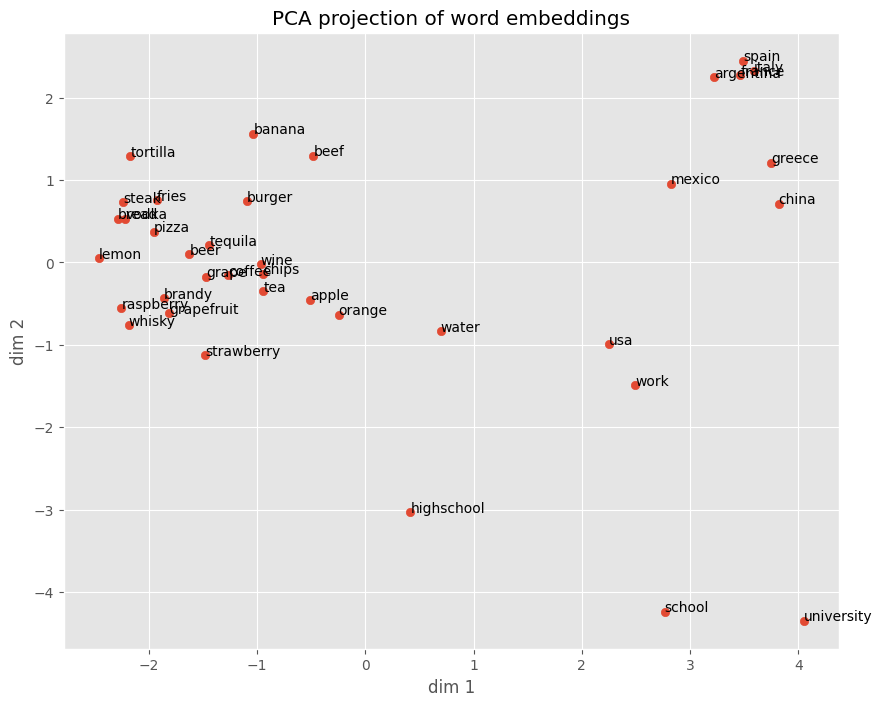

array([[-1.0925041 ,  0.74372876],
       [-2.1670628 ,  1.292367  ],
       [-2.2834158 ,  0.52902204],
       [-1.9500184 ,  0.3721772 ],
       [-0.47766322,  1.2940513 ],
       [-2.2378066 ,  0.7307441 ],
       [-1.92657   ,  0.75569266],
       [-0.9450014 , -0.13504937],
       [ 3.2193754 ,  2.246692  ],
       [ 2.8189163 ,  0.95552075],
       [ 3.488131  ,  2.4482503 ],
       [ 2.2472813 , -0.9943583 ],
       [ 3.4618902 ,  2.269228  ],
       [ 3.5916219 ,  2.3245144 ],
       [ 3.7501671 ,  1.2115402 ],
       [ 3.8158362 ,  0.7147594 ],
       [ 0.69911534, -0.83254534],
       [-1.6239517 ,  0.10265356],
       [-1.439923  ,  0.20648277],
       [-0.962911  , -0.02196907],
       [-2.1817415 , -0.7590347 ],
       [-1.8575069 , -0.43355262],
       [-2.2137516 ,  0.52904844],
       [-1.2642858 , -0.15639098],
       [-0.9421787 , -0.34516948],
       [-0.5101739 , -0.45191413],
       [-1.033432  ,  1.5628412 ],
       [-0.24471143, -0.6360452 ],
       [-2.4575224 ,

In [11]:
# 
plot_embeddings(PATH, words, emb_dim, embeddings_dict, PCA)

### Visualizing embeddings with t‑SNE

In addition to PCA, we use t‑SNE (t‑Distributed Stochastic Neighbor Embedding) to visualize the word embeddings.  
t‑SNE is a nonlinear dimensionality reduction method that focuses on preserving local neighborhoods, meaning that words that are close in the original space remain close in 2D.  
This often produces clearer, more separated clusters than PCA, especially for groups of semantically similar words.  
However, global distances between far‑away clusters in a t‑SNE plot should be interpreted with caution, since t‑SNE mainly preserves local structure.


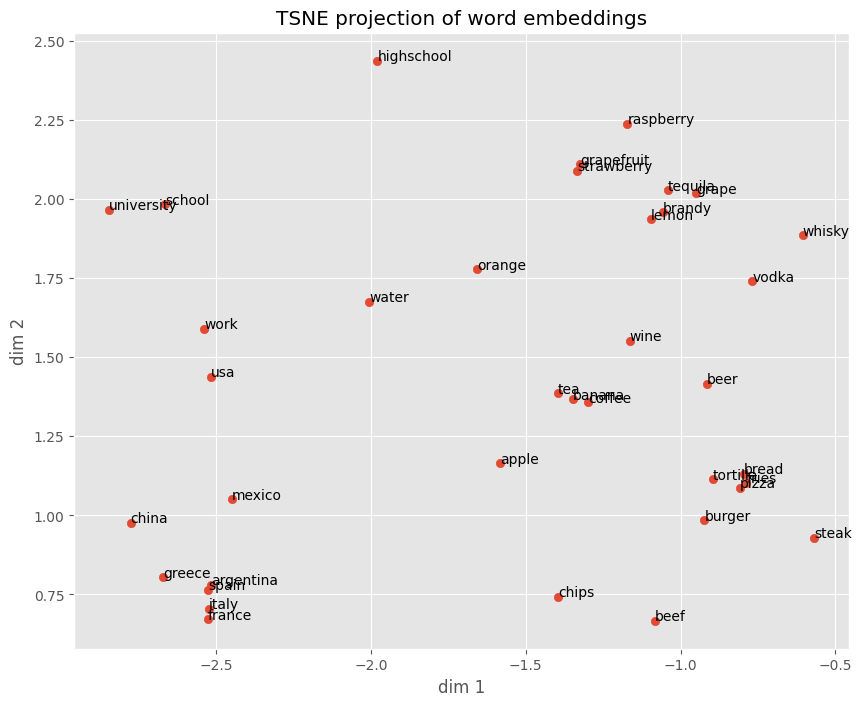

In [12]:
# t-SNE dimensionality reduction for visualization
embeddings = plot_embeddings(PATH, words, emb_dim, embeddings_dict, TSNE)

### Let us compute analogies

### Cosine similarity between word vectors

To measure how similar two word embeddings are, we use cosine similarity.  
Each word is represented as a vector in a high‑dimensional space, and cosine similarity measures the angle between two such vectors.

The cosine similarity of two vectors \(u\) and \(v\) is defined as:

$$
\text{cosine\_similarity}(u, v) = \frac{u \cdot v}{\|u\|\|v\|}
$$

More explicitly, if the vectors have dimension \(d\):

$$
\text{cosine\_similarity}(u, v) =
\frac{\sum_{i=1}^{d} u_i v_i}{\sqrt{\sum_{i=1}^{d} u_i^2}\,\sqrt{\sum_{i=1}^{d} v_i^2}}
$$

Values close to 1 indicate that the vectors point in almost the same direction (high similarity), values near 0 indicate no relation, and values near −1 indicate opposite directions.



In [13]:
def cosine_similarity(vec1, vec2):
    
    # Cosine similarity = dot(v1, v2) / (||v1|| * ||v2||)
    return np.dot(vec1, vec2) / (norm(vec1) * norm(vec2))



### Word analogies with vector arithmetic

Word embeddings represent words as vectors in such a way that semantic relationships correspond to directions in the vector space.  
We can solve analogies of the form:

$$
\text{word1} : \text{word2} :: \text{word3} : ?
$$

using simple vector arithmetic.  
Let `v_word1`, `v_word2`, `v_word3` be the embedding vectors of the three words.  
We compute a target vector:

$$
v_{target} = v_{word2} - v_{word1} + v_{word3}
$$

Then we search over the vocabulary for the word whose embedding `v` has the highest cosine similarity with `v_target`.  
For example, for the analogy “man : king :: woman : ?”, the target vector

$$
v_{king} - v_{man} + v_{woman}
$$

is typically closest to the embedding of “queen”.



In [14]:
# analogy

def analogy(word1, word2, word3, embeddings_dict, top_n=5):
    """
    Solve analogies of the form:
    word1 is to word2 as word3 is to ?
    
    Example:
    word1 = 'man', word2 = 'king', word3 = 'woman'
    """

    # 1) Check that all words exist in the dictionary
    for w in (word1, word2, word3):
        if w not in embeddings_dict:
            raise ValueError(f'Word {w} not in vocabulary')
    
    # 2) Get their vectors

    v1 = embeddings_dict[word1]
    v2 = embeddings_dict[word2]
    v3 = embeddings_dict[word3]
    
    # 3) Compute target vector: v2 - v1 + v3

    target_vec = v2 - v1 + v3
    
    # 4) Compute cosine similarity between target_vec and every other word

    similarities = [] # list of (word, similarity) tuples
    
    for w, v in embeddings_dict.items():

        # Optionally skip the words used in the query
        if w in {word1, word2, word3}:
            continue
        sim = cosine_similarity(target_vec, v)
        similarities.append((w, sim))
    
    # 5) Sort by similarity (descending) and return top_n

    similarities.sort(key=lambda x: x[1], reverse=True)
    
    return similarities[:top_n]

In [15]:
analogy('man', 'king', 'woman', embeddings_dict)

[('queen', 0.86095816),
 ('daughter', 0.76845115),
 ('prince', 0.7640699),
 ('throne', 0.763497),
 ('princess', 0.7512728)]

### Finding most similar words with cosine similarity

To measure how similar two word embeddings are, we use cosine similarity, which compares the angle between their vectors.  
The function `find_most_similar` takes a query word, computes the cosine similarity between its embedding and every other embedding in the dictionary, and returns the top‑N most similar words.  
This allows us to explore the neighborhood of a word in embedding space, revealing words with similar meanings or contexts.  
For example, querying with “mexico” typically returns other country names, indicating that the embedding correctly places related countries near each other in the vector space.


In [16]:
# most similar

def find_most_similar(word, embeddings_dict, top_n=10):
    """
    Return the top_n most similar words to the input word
    based on cosine similarity of their embeddings.
    """

    # 1) Check that the word exists
    if word not in embeddings_dict:
        raise ValueError(f'Word {word} not in vocabulary')
    
    # 2) Get the vector of the input word
    target_vec = embeddings_dict[word]
    
    # 3) Compute cosine similarity with every other word
    similarities = []
    
    for w, v in embeddings_dict.items():
        if w == word:          # skip the word itself
            continue
        sim = cosine_similarity(target_vec, v)
        similarities.append((w, sim))
    
    # 4) Sort by similarity (highest first)
    similarities.sort(key=lambda x: x[1], reverse=True)
    
    # 5) Return top_n results
    return similarities[:top_n]

In [17]:
most_similar = find_most_similar('mexico', embeddings_dict)

In [18]:
for i, w in enumerate(most_similar, 1):
    print(f'{i} ---> {w[0]}')

1 ---> mexican
2 ---> venezuela
3 ---> colombia
4 ---> peru
5 ---> chile
6 ---> puerto
7 ---> rico
8 ---> cuba
9 ---> guatemala
10 ---> panama
